In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
base_model_results = pd.read_csv("results/base_model_results.csv")
large_model_results = pd.read_csv("results/large_model_results.csv")
huge_model_results = pd.read_csv("results/huge_model_results.csv")
pretrained_base_model_results = pd.read_csv("results/pretrained_base_model_results.csv")
pretrained_large_model_results = pd.read_csv("results/pretrained_large_model_results.csv")
pretrained_huge_model_results = pd.read_csv("results/pretrained_huge_model_results.csv")

In [ ]:
dice_diff_dict = {
    "Base": {
        "LV": pretrained_base_model_results["seg_2_dice"].iloc[0] - base_model_results["seg_2_dice"].iloc[0],
        "RV": pretrained_base_model_results["seg_3_dice"].iloc[0] - base_model_results["seg_3_dice"].iloc[0],
        "Myo": pretrained_base_model_results["seg_4_dice"].iloc[0] - base_model_results["seg_4_dice"].iloc[0],
        "Avg": pretrained_base_model_results["dice_avg"].iloc[0] - base_model_results["dice_avg"].iloc[0],
    },
    "Large": {
        "LV": pretrained_large_model_results["seg_2_dice"].iloc[0] - large_model_results["seg_2_dice"].iloc[0],
        "RV": pretrained_large_model_results["seg_3_dice"].iloc[0] - large_model_results["seg_3_dice"].iloc[0],
        "Myo": pretrained_large_model_results["seg_4_dice"].iloc[0] - large_model_results["seg_4_dice"].iloc[0],
        "Avg": pretrained_large_model_results["dice_avg"].iloc[0] - large_model_results["dice_avg"].iloc[0],
    },
    "Huge": {
        "LV": pretrained_huge_model_results["seg_2_dice"].iloc[0] - huge_model_results["seg_2_dice"].iloc[0],
        "RV": pretrained_huge_model_results["seg_3_dice"].iloc[0] - huge_model_results["seg_3_dice"].iloc[0],
        "Myo": pretrained_huge_model_results["seg_4_dice"].iloc[0] - huge_model_results["seg_4_dice"].iloc[0],
        "Avg": pretrained_huge_model_results["dice_avg"].iloc[0] - huge_model_results["dice_avg"].iloc[0],
    }
}

# Convert to long-form dataframe
dice_diff = (
    pd.DataFrame(dice_diff_dict)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

# Melt into long format
dice_long = dice_diff.melt(id_vars="Model", var_name="Segment", value_name="Diff")
dice_long

,Model,Segment,Diff
0,Base,LV,-0.000050
1,Large,LV,0.000897
2,Huge,LV,-0.000197
3,Base,RV,0.000095
4,Large,RV,0.001063
5,Huge,RV,-0.000246
6,Base,Myo,0.000009
7,Large,Myo,0.000112
8,Huge,Myo,-0.000371
9,Base,Avg,0.000018


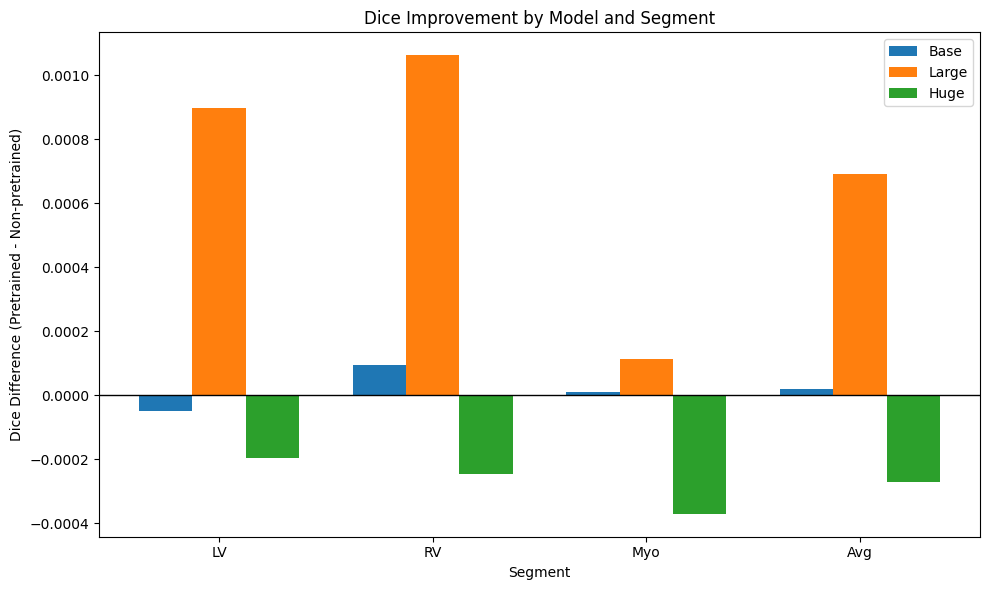

In [51]:
plt.figure(figsize=(10, 6))

segments = ["LV", "RV", "Myo", "Avg"]
x = range(len(segments))

# Plot each model as an offset bar group
bar_width = 0.25

for i, model in enumerate(["Base", "Large", "Huge"]):
    model_values = dice_long[dice_long["Model"] == model]["Diff"]
    plt.bar([xi + i*bar_width for xi in x],
            model_values,
            width=bar_width,
            label=model)

plt.axhline(0, linewidth=1, color='black')
plt.xticks([xi + bar_width for xi in x], segments)
plt.ylabel("Dice Difference (Pretrained - Non-pretrained)")
plt.xlabel("Segment")
plt.title("Dice Improvement by Model and Segment")
plt.legend()
plt.tight_layout()
plt.savefig("dice_improvement.png", dpi=300)
plt.show()


In [40]:
# Build per-model dicts instead of per-column dataframes
hd_diff_dict = {
    "Base": {
        "LV": pretrained_base_model_results["seg_2_hd"].iloc[0] - base_model_results["seg_2_hd"].iloc[0],
        "RV": pretrained_base_model_results["seg_3_hd"].iloc[0] - base_model_results["seg_3_hd"].iloc[0],
        "Myo": pretrained_base_model_results["seg_4_hd"].iloc[0] - base_model_results["seg_4_hd"].iloc[0],
        "Avg": pretrained_base_model_results["hd_avg"].iloc[0] - base_model_results["hd_avg"].iloc[0],
    },
    "Large": {
        "LV": pretrained_large_model_results["seg_2_hd"].iloc[0] - large_model_results["seg_2_hd"].iloc[0],
        "RV": pretrained_large_model_results["seg_3_hd"].iloc[0] - large_model_results["seg_3_hd"].iloc[0],
        "Myo": pretrained_large_model_results["seg_4_hd"].iloc[0] - large_model_results["seg_4_hd"].iloc[0],
        "Avg": pretrained_large_model_results["hd_avg"].iloc[0] - large_model_results["hd_avg"].iloc[0],
    },
    "Huge": {
        "LV": pretrained_huge_model_results["seg_2_hd"].iloc[0] - huge_model_results["seg_2_hd"].iloc[0],
        "RV": pretrained_huge_model_results["seg_3_hd"].iloc[0] - huge_model_results["seg_3_hd"].iloc[0],
        "Myo": pretrained_huge_model_results["seg_4_hd"].iloc[0] - huge_model_results["seg_4_hd"].iloc[0],
        "Avg": pretrained_huge_model_results["hd_avg"].iloc[0] - huge_model_results["hd_avg"].iloc[0],
    }
}

# Convert to long-form dataframe
hd_diff = (
    pd.DataFrame(hd_diff_dict)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

# Melt into long format
hd_long = hd_diff.melt(id_vars="Model", var_name="Segment", value_name="Diff")
hd_long

,Model,Segment,Diff
0,Base,LV,-0.008380
1,Large,LV,0.006380
2,Huge,LV,0.007454
3,Base,RV,-0.010740
4,Large,RV,0.005947
5,Huge,RV,0.009675
6,Base,Myo,0.000000
7,Large,Myo,-0.006958
8,Huge,Myo,0.000000
9,Base,Avg,-0.006373


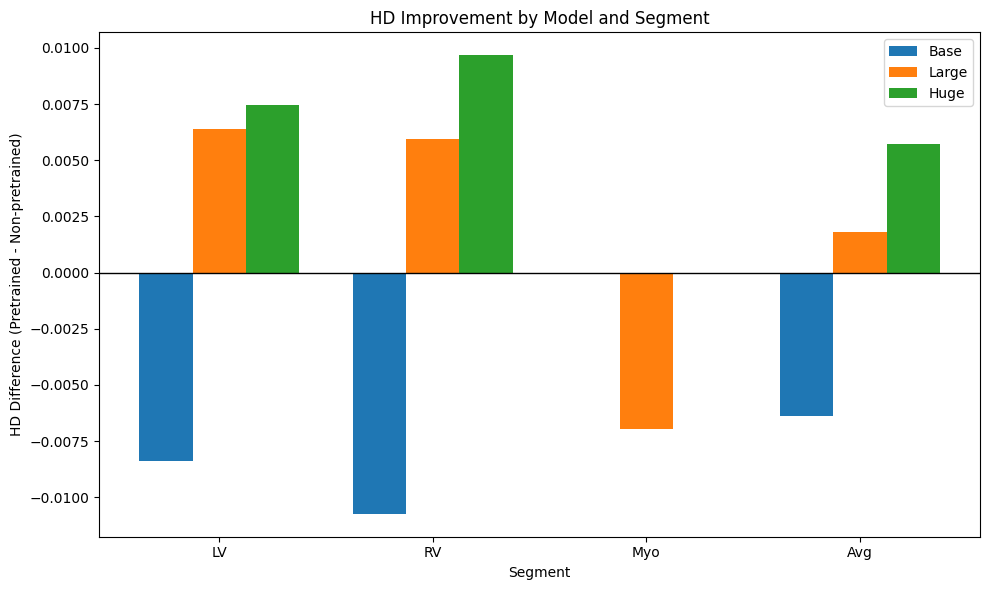

In [50]:
plt.figure(figsize=(10, 6))

segments = ["LV", "RV", "Myo", "Avg"]
x = range(len(segments))

# Plot each model as an offset bar group
bar_width = 0.25

for i, model in enumerate(["Base", "Large", "Huge"]):
    model_values = hd_long[hd_long["Model"] == model]["Diff"]
    plt.bar([xi + i*bar_width for xi in x],
            model_values,
            width=bar_width,
            label=model)

plt.axhline(0, linewidth=1, color='black')
plt.xticks([xi + bar_width for xi in x], segments)
plt.ylabel("HD Difference (Pretrained - Non-pretrained)")
plt.xlabel("Segment")
plt.title("HD Improvement by Model and Segment")
plt.legend()
plt.tight_layout()
plt.savefig("hd_improvement.png", dpi=300)
plt.show()


In [47]:
# Build per-model dicts instead of per-column dataframes
flow_diff_dict = {
    "Base": {
        "x": pretrained_base_model_results["x_flow_mag_avg"].iloc[0] - base_model_results["x_flow_mag_avg"].iloc[0],
        "y": pretrained_base_model_results["y_flow_mag_avg"].iloc[0] - base_model_results["y_flow_mag_avg"].iloc[0],
        "z": pretrained_base_model_results["z_flow_mag_avg"].iloc[0] - base_model_results["z_flow_mag_avg"].iloc[0],
    },
    "Large": {
        "x": pretrained_large_model_results["x_flow_mag_avg"].iloc[0] - large_model_results["x_flow_mag_avg"].iloc[0],
        "y": pretrained_large_model_results["y_flow_mag_avg"].iloc[0] - large_model_results["y_flow_mag_avg"].iloc[0],
        "z": pretrained_large_model_results["z_flow_mag_avg"].iloc[0] - large_model_results["z_flow_mag_avg"].iloc[0],
    },
    "Huge": {
        "x": pretrained_huge_model_results["x_flow_mag_avg"].iloc[0] - huge_model_results["x_flow_mag_avg"].iloc[0],
        "y": pretrained_huge_model_results["y_flow_mag_avg"].iloc[0] - huge_model_results["y_flow_mag_avg"].iloc[0],
        "z": pretrained_huge_model_results["z_flow_mag_avg"].iloc[0] - huge_model_results["z_flow_mag_avg"].iloc[0],
    }
}

# Convert to long-form dataframe
flow_diff = (
    pd.DataFrame(flow_diff_dict)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

# Melt into long format
flow_long = flow_diff.melt(id_vars="Model", var_name="Segment", value_name="Diff")
flow_long

,Model,Segment,Diff
0,Base,x,-0.019851
1,Large,x,-0.025979
2,Huge,x,-0.065555
3,Base,y,0.014698
4,Large,y,-0.041737
5,Huge,y,-0.030543
6,Base,z,-0.003323
7,Large,z,-0.020871
8,Huge,z,-0.001768


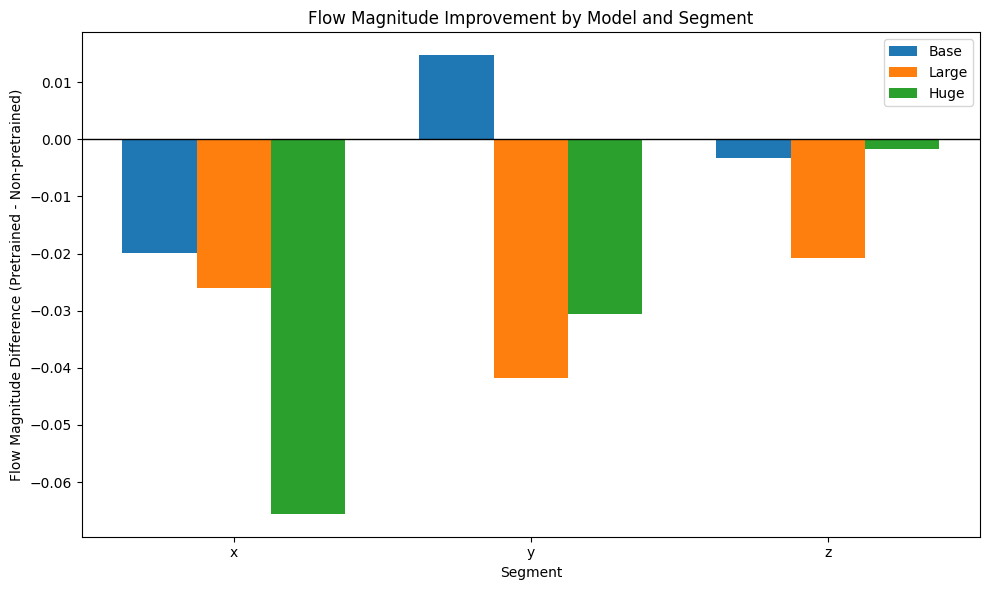

In [49]:
plt.figure(figsize=(10, 6))

segments = ["x", "y", "z"]
x = range(len(segments))

# Plot each model as an offset bar group
bar_width = 0.25

for i, model in enumerate(["Base", "Large", "Huge"]):
    model_values = flow_long[flow_long["Model"] == model]["Diff"]
    plt.bar([xi + i*bar_width for xi in x],
            model_values,
            width=bar_width,
            label=model)

plt.axhline(0, linewidth=1, color='black')
plt.xticks([xi + bar_width for xi in x], segments)
plt.ylabel("Flow Magnitude Difference (Pretrained - Non-pretrained)")
plt.xlabel("Segment")
plt.title("Flow Magnitude Improvement by Model and Segment")
plt.legend()
plt.tight_layout()
plt.savefig("flow_magnitude_improvement.png", dpi=300)
plt.show()
